In [7]:
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
path_baseline = "../data/analytics/model_results/MED-FISC/con_exog/baseline/validation_metrics_all_steps_baseline.csv"
df_base_line = pd.read_csv(path_baseline)
df_base_line["model"] = df_base_line["model"].replace({"NaiveByLag": "Baseline"})
df_base_line.head()

,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,Baseline,4.604501,3.049310,21.201427,0.466912,0.314311,"{""1"": 0.3143106538149735}"
1,2,Baseline,5.772199,3.891036,33.318279,0.162246,0.401072,"{""1"": 0.3167435990160012, ""2"": 0.484713713112064}"
2,3,Baseline,6.621614,4.530385,43.845772,-0.102457,0.466974,"{""1"": 0.302092199082798, ""2"": 0.49351601205246..."
3,4,Baseline,6.996139,4.828710,48.945967,-0.230696,0.497724,"{""1"": 0.3001800728698186, ""2"": 0.4702934626470..."
4,5,Baseline,7.453191,5.228893,55.550049,-0.396749,0.538973,"{""1"": 0.31247379071437514, ""2"": 0.506163540371..."


In [9]:
path_lstm = "../data/analytics/model_results/MED-FISC/con_exog/lstm/validation_metrics_all_steps_direct.csv"
df_lstm = pd.read_csv(path_lstm)
df_lstm.head()


,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,LSTM,3.091677,2.199914,9.558469,0.759662,0.226758,"{""1"": 0.2267583351011548}"
1,2,LSTM,4.022820,3.159275,16.183083,0.593093,0.325645,"{""1"": 0.30425813725559636, ""2"": 0.346858394061..."
2,3,LSTM,4.392262,3.413192,19.291962,0.514923,0.351818,"{""1"": 0.31147302758363415, ""2"": 0.347013327768..."
3,4,LSTM,4.715141,3.379590,22.232558,0.440985,0.348355,"{""1"": 0.3245844641334893, ""2"": 0.3294292975380..."
4,5,LSTM,5.206638,3.945603,27.109077,0.318370,0.406697,"{""1"": 0.38034747260933355, ""2"": 0.400991261288..."


In [10]:
path_direct = "../data/analytics/model_results/MED-FISC/con_exog/direct/validation_metrics_all_steps_direct.csv"
df_direct = pd.read_csv(path_direct)
df_direct["model"] = df_direct["model"].replace(
    {"LGBM": "LGBM direct", "XGBoost": "XGBoost direct"}
)
df_direct.head()

,step,model,rmse,mae,mse,r2,wmape,stepwise_wmape
0,1,LGBM direct,3.296530,2.298176,10.867110,0.726758,0.236887,"{""1"": 0.23688676827258387}"
1,1,LGBM direct,3.296530,2.298176,10.867110,0.726758,0.236887,"{""1"": 0.23688676827258387}"
2,1,XGBoost direct,3.546153,2.449801,12.575200,0.683810,0.252516,"{""1"": 0.25251565785251084}"
3,1,XGBoost direct,3.546153,2.449801,12.575200,0.683810,0.252516,"{""1"": 0.25251565785251084}"
4,2,LGBM direct,3.651284,2.572933,13.331877,0.664784,0.265208,"{""1"": 0.23610355564110835, ""2"": 0.294074505045..."


In [11]:
path_simple = "../data/analytics/model_results/MED-FISC/con_exog/validation_metrics_all_steps_direct.csv"
df = pd.read_csv(path_simple)
df["model"] = df["model"].replace(
    {"LGBM": "LGBM recursive", "XGBoost": "XGBoost recursive"}
)


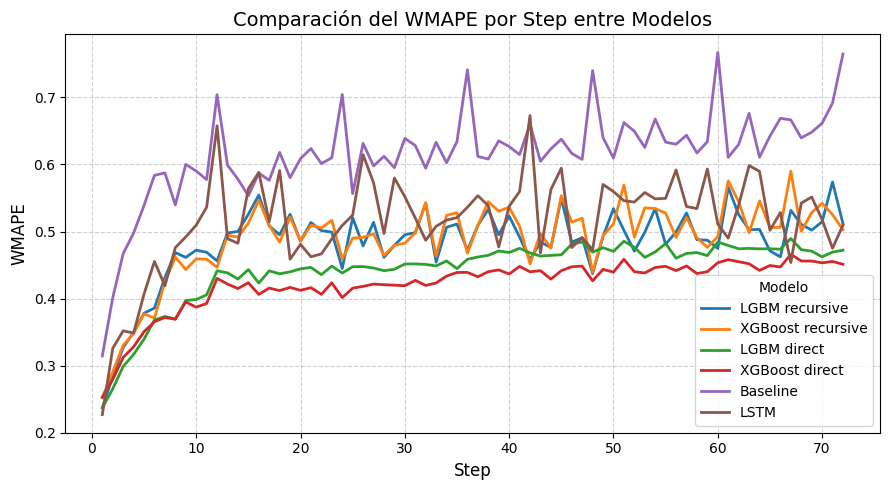

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Unir los dos DataFrames ---
df_all = pd.concat([df, df_direct, df_base_line, df_lstm], ignore_index=True)

# --- Graficar las tres líneas ---
plt.figure(figsize=(9, 5))

for model in df_all["model"].unique():
    subset = df_all[df_all["model"] == model]
    plt.plot(subset["step"], subset["wmape"], marker="", linewidth=2, label=model)

# --- Personalizar ---
plt.title("Comparación del WMAPE por Step entre Modelos", fontsize=14)
plt.xlabel("Step", fontsize=12)
plt.ylabel("WMAPE", fontsize=12)
plt.legend(title="Modelo", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()
